In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [25]:
ratings = pd.read_csv(
    "../dataset/ml-100k/u.data",
    sep="\t",
    names=["user_id", "movie_id", "rating", "timestamp"]
)

In [26]:
movies = pd.read_csv(
    "../dataset/ml-100k/u.item",
    sep="|",
    encoding="latin-1",
    header=None,
    usecols=[0, 1],
    names=["movie_id", "title"]
)

In [27]:
data = pd.merge(ratings, movies, on="movie_id")

In [28]:
data.head()

,user_id,movie_id,rating,timestamp,title
0,196,242,3,881250949,Kolya (1996)
1,186,302,3,891717742,L.A. Confidential (1997)
2,22,377,1,878887116,Heavyweights (1994)
3,244,51,2,880606923,Legends of the Fall (1994)
4,166,346,1,886397596,Jackie Brown (1997)


In [29]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   user_id    100000 non-null  int64 
 1   movie_id   100000 non-null  int64 
 2   rating     100000 non-null  int64 
 3   timestamp  100000 non-null  int64 
 4   title      100000 non-null  object
dtypes: int64(4), object(1)
memory usage: 3.8+ MB


In [30]:
print(data.shape)

(100000, 5)


In [31]:
print(data.isnull().sum())

user_id      0
movie_id     0
rating       0
timestamp    0
title        0
dtype: int64


In [32]:
print(data.duplicated().sum())

0


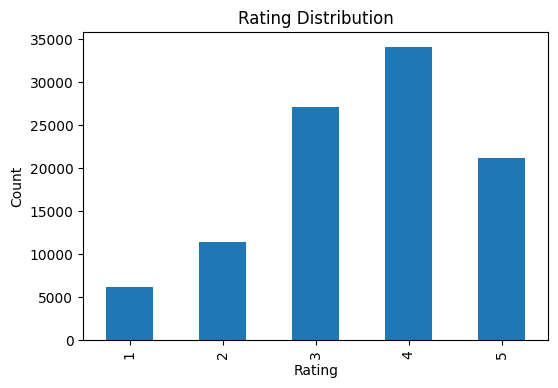

In [33]:
data["rating"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.show()

In [34]:
print("Users :", data["user_id"].nunique())

print("Movies:", data["movie_id"].nunique())

Users : 943
Movies: 1682


In [35]:
data = data.drop_duplicates()

In [36]:
print(data.isnull().sum())

user_id      0
movie_id     0
rating       0
timestamp    0
title        0
dtype: int64


In [37]:
data["rating"].describe()

count    100000.000000
mean          3.529860
std           1.125674
min           1.000000
25%           3.000000
50%           4.000000
75%           4.000000
max           5.000000
Name: rating, dtype: float64

In [38]:
top_movies = data.groupby("title")["rating"].count()

top_movies = top_movies.sort_values(ascending=False)

top_movies.head(10)

title
Star Wars (1977)                 583
Contact (1997)                   509
Fargo (1996)                     508
Return of the Jedi (1983)        507
Liar Liar (1997)                 485
English Patient, The (1996)      481
Scream (1996)                    478
Toy Story (1995)                 452
Air Force One (1997)             431
Independence Day (ID4) (1996)    429
Name: rating, dtype: int64

In [39]:
average_rating = data.groupby("title")["rating"].mean()

average_rating.sort_values(ascending=False).head(10)

title
Aiqing wansui (1994)                                 5.0
Entertaining Angels: The Dorothy Day Story (1996)    5.0
Santa with Muscles (1996)                            5.0
Prefontaine (1997)                                   5.0
They Made Me a Criminal (1939)                       5.0
Saint of Fort Washington, The (1993)                 5.0
Great Day in Harlem, A (1994)                        5.0
Star Kid (1997)                                      5.0
Marlene Dietrich: Shadow and Light (1996)            5.0
Someone Else's America (1995)                        5.0
Name: rating, dtype: float64

In [40]:
user_item = data.pivot_table(
    index="user_id",
    columns="title",
    values="rating"
)

In [41]:
user_item

title,'Til There Was You (1997),1-900 (1994),101 Dalmatians (1996),12 Angry Men (1957),187 (1997),2 Days in the Valley (1996),"20,000 Leagues Under the Sea (1954)",2001: A Space Odyssey (1968),3 Ninjas: High Noon At Mega Mountain (1998),"39 Steps, The (1935)",...,Yankee Zulu (1994),Year of the Horse (1997),You So Crazy (1994),Young Frankenstein (1974),Young Guns (1988),Young Guns II (1990),"Young Poisoner's Handbook, The (1995)",Zeus and Roxanne (1997),unknown,Á köldum klaka (Cold Fever) (1994)
user_id,,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,2.0,5.0,NaN,NaN,3.0,4.0,NaN,NaN,...,NaN,NaN,NaN,5.0,3.0,NaN,NaN,NaN,4.0,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,2.0,NaN,NaN,NaN,NaN,4.0,NaN,NaN,...,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN,4.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
939,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
940,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
941,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [42]:
print(user_item.shape)

(943, 1664)


In [43]:
print(user_item.isnull().sum().sum())

1469459


In [44]:
user_item = user_item.fillna(0)

In [45]:
user_item.head()

title,'Til There Was You (1997),1-900 (1994),101 Dalmatians (1996),12 Angry Men (1957),187 (1997),2 Days in the Valley (1996),"20,000 Leagues Under the Sea (1954)",2001: A Space Odyssey (1968),3 Ninjas: High Noon At Mega Mountain (1998),"39 Steps, The (1935)",...,Yankee Zulu (1994),Year of the Horse (1997),You So Crazy (1994),Young Frankenstein (1974),Young Guns (1988),Young Guns II (1990),"Young Poisoner's Handbook, The (1995)",Zeus and Roxanne (1997),unknown,Á köldum klaka (Cold Fever) (1994)
user_id,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,2.0,5.0,0.0,0.0,3.0,4.0,0.0,0.0,...,0.0,0.0,0.0,5.0,3.0,0.0,0.0,0.0,4.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,2.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,...,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,4.0,0.0


In [46]:
from surprise import Dataset
from surprise import Reader
from surprise import SVD
from surprise.model_selection import train_test_split

In [47]:
reader = Reader(rating_scale=(1, 5))

dataset = Dataset.load_from_df(
    data[["user_id", "movie_id", "rating"]],
    reader
)

In [48]:
trainset, testset = train_test_split(
    dataset,
    test_size=0.2,
    random_state=42
)

In [49]:
model = SVD()

In [50]:
model.fit(trainset)

In [51]:
predictions = model.test(testset)

In [52]:
for prediction in predictions[:10]:
    print(prediction)

user: 907        item: 143        r_ui = 5.00   est = 4.98   {'was_impossible': False}
user: 371        item: 210        r_ui = 4.00   est = 4.07   {'was_impossible': False}
user: 218        item: 42         r_ui = 4.00   est = 3.43   {'was_impossible': False}
user: 829        item: 170        r_ui = 4.00   est = 3.97   {'was_impossible': False}
user: 733        item: 277        r_ui = 1.00   est = 3.33   {'was_impossible': False}
user: 363        item: 1512       r_ui = 1.00   est = 3.18   {'was_impossible': False}
user: 193        item: 487        r_ui = 5.00   est = 3.93   {'was_impossible': False}
user: 808        item: 313        r_ui = 5.00   est = 4.76   {'was_impossible': False}
user: 557        item: 682        r_ui = 2.00   est = 3.20   {'was_impossible': False}
user: 774        item: 196        r_ui = 3.00   est = 2.68   {'was_impossible': False}


In [53]:
prediction = model.predict(1, 50)

print("Estimated Rating:", round(prediction.est, 2))

Estimated Rating: 5


In [54]:
movies_list = data["movie_id"].unique()

recommendations = []

for movie in movies_list:
    prediction = model.predict(1, movie)

    recommendations.append(
        (movie, prediction.est)
    )

In [55]:
recommendations = sorted(
    recommendations,
    key=lambda x: x[1],
    reverse=True
)

In [56]:
top_movies = []

for movie_id, score in recommendations[:10]:
    title = movies.loc[
        movies["movie_id"] == movie_id,
        "title"
    ].values[0]

    top_movies.append({
        "Movie": title,
        "Predicted Rating": round(score, 2)
    })

pd.DataFrame(top_movies)

,Movie,Predicted Rating
0,Star Wars (1977),5.00
1,Hoop Dreams (1994),4.83
2,Casablanca (1942),4.83
3,"Usual Suspects, The (1995)",4.83
4,"Wrong Trousers, The (1993)",4.82
5,Nikita (La Femme Nikita) (1990),4.79
6,Lone Star (1996),4.77
7,"Bridge on the River Kwai, The (1957)",4.76
8,Toy Story (1995),4.73
9,To Kill a Mockingbird (1962),4.71


In [57]:
import joblib

joblib.dump(
    model,
    "../models/recommendation_model.pkl"
)

['../models/recommendation_model.pkl']

In [58]:
from surprise import accuracy

In [59]:
rmse = accuracy.rmse(predictions)

RMSE: 0.9364


In [60]:
results = []

for prediction in predictions:
    results.append({
        "Actual": prediction.r_ui,
        "Predicted": round(prediction.est, 2)
    })

results = pd.DataFrame(results)

results.head()

,Actual,Predicted
0,5.0,4.98
1,4.0,4.07
2,4.0,3.43
3,4.0,3.97
4,1.0,3.33


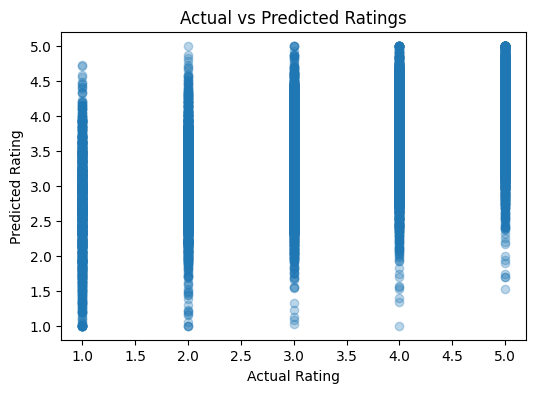

In [61]:
plt.figure(figsize=(6,4))

plt.scatter(
    results["Actual"],
    results["Predicted"],
    alpha=0.3
)

plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Actual vs Predicted Ratings")

plt.savefig("../images/predictions.png")

plt.show()

In [62]:
def precision_at_k(predictions, k=10, threshold=4):

    user_predictions = {}

    for prediction in predictions:
        user_predictions.setdefault(prediction.uid, []).append(prediction)

    scores = []

    for user, ratings in user_predictions.items():

        ratings.sort(key=lambda x: x.est, reverse=True)

        top_k = ratings[:k]

        recommended = sum(p.est >= threshold for p in top_k)

        relevant = sum((p.est >= threshold and p.r_ui >= threshold) for p in top_k)

        if recommended > 0:
            scores.append(relevant / recommended)

    return sum(scores) / len(scores)

In [63]:
def recall_at_k(predictions, k=10, threshold=4):

    user_predictions = {}

    for prediction in predictions:
        user_predictions.setdefault(prediction.uid, []).append(prediction)

    scores = []

    for user, ratings in user_predictions.items():

        ratings.sort(key=lambda x: x.est, reverse=True)

        top_k = ratings[:k]

        relevant = sum(p.r_ui >= threshold for p in ratings)

        recommended = sum((p.est >= threshold and p.r_ui >= threshold) for p in top_k)

        if relevant > 0:
            scores.append(recommended / relevant)

    return sum(scores) / len(scores)

In [64]:
precision = precision_at_k(predictions)

recall = recall_at_k(predictions)

print("Precision@10:", round(precision, 3))

print("Recall@10:", round(recall, 3))

Precision@10: 0.839
Recall@10: 0.292


In [65]:
summary = pd.DataFrame({
    "Metric": [
        "RMSE",
        "Precision@10",
        "Recall@10"
    ],
    "Value": [
        round(rmse,3),
        round(precision,3),
        round(recall,3)
    ]
})

summary

,Metric,Value
0,RMSE,0.936
1,Precision@10,0.839
2,Recall@10,0.292


In [66]:
print("User Satisfaction Analysis")

if precision > 0.8:
    print("The recommendation quality is high and most recommended movies are relevant.")
elif precision > 0.6:
    print("The recommendation quality is good with room for improvement.")
else:
    print("The recommendation quality is moderate and can be improved with more data.")

User Satisfaction Analysis
The recommendation quality is high and most recommended movies are relevant.
